# Brain Tumor MRI Classification & Explainable AI
This notebook contains the complete pipeline for training a lightweight, highly accurate Convolutional Neural Network (MobileNetV2) to classify brain tumors from MRI scans. It also includes Explainable AI (XAI) techniques to visualize the model's decision-making process.

**Target Classes:** 
- Glioma
- Meningioma
- Pituitary
- No Tumor

### Project Pipeline
1. **Data Preprocessing & Augmentation**: Loading images and generating augmented variations to prevent overfitting.
2. **Transfer Learning**: Utilizing a pre-trained MobileNetV2 model for feature extraction.
3. **Class Balancing**: Addressing dataset imbalances automatically through class weights.
4. **Fine-Tuning**: Unfreezing top layers and training with a very low learning rate for maximum accuracy.
5. **Grad-CAM (Gradient-weighted Class Activation Mapping)**: Generating heatmaps to provide visual explanations for the AI's clinical predictions.

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [2]:
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: []


In [5]:
dataset_path = './dataset'

In [6]:
print(f"Contents of {dataset_path}: {os.listdir(dataset_path)}")

train_sub_path = os.path.join(dataset_path, 'train')
test_sub_path = os.path.join(dataset_path, 'test')

print(f"Contents of {train_sub_path}: {os.listdir(train_sub_path)}")
print(f"Contents of {test_sub_path}: {os.listdir(test_sub_path)}")

Contents of ./dataset: ['.DS_Store', 'test', 'train']
Contents of ./dataset/train: ['pituitary', '.DS_Store', 'notumor', 'glioma', 'meningioma']
Contents of ./dataset/test: ['pituitary', 'notumor', 'glioma', 'meningioma']


## 1. Data Preprocessing & Augmentation
We use `ImageDataGenerator` to load images in batches and apply real-time data augmentation (rotations, zooms, flips). We also apply the specific `preprocess_input` step required by the MobileNetV2 architecture.

In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 3
SEED = 42

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [7]:
train_data = train_gen.flow_from_directory(
    os.path.join(dataset_path, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_path = os.path.join(dataset_path, 'val')
if not os.path.isdir(val_path):
    print("Warning: './dataset/val' not found. Using './dataset/test' as validation data.")
    val_path = os.path.join(dataset_path, 'test')

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('Class indices:', train_data.class_indices)

Found 5723 images belonging to 4 classes.
Found 1430 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 2. Model Architecture (MobileNetV2)
We utilize **Transfer Learning** with a pre-trained **MobileNetV2** base model, which is highly efficient. The base layers are frozen, and a custom classification head (`GlobalAveragePooling2D` -> `Dense(128)` -> `Dropout(0.2)` -> `Dense(4)`) is attached to learn the specific features of our four tumor classes.

In [8]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(4, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 3. Addressing Class Imbalance
Medical datasets frequently suffer from class imbalance. We compute and apply **Class Weights** based on the frequency of `Glioma`, `Meningioma`, `Pituitary`, and `No Tumor` to ensure the model does not become biased toward the most common class.

In [31]:
from sklearn.utils.class_weight import compute_class_weight

# ============ STEP 1: Check class distribution ============
print("=" * 60)
print("🔍 STEP 1: Class Distribution Check")
print("=" * 60)

class_indices_dict = train_data.class_indices
print(f"\nClass indices mapping: {class_indices_dict}")

train_classes = train_data.classes
unique_classes = np.unique(train_classes)

print("\nClass distribution in TRAINING data:")
for class_idx in unique_classes:
    count = np.sum(train_classes == class_idx)
    class_name = list(class_indices_dict.keys())[list(class_indices_dict.values()).index(class_idx)]
    percentage = (count / len(train_classes)) * 100
    print(f"  {class_name:12} (idx {class_idx}): {count:4d} samples ({percentage:5.1f}%)")

# ============ STEP 2: Compute class weights ============
print("\n" + "=" * 60)
print("⚖️  STEP 2: Computing Balanced Class Weights")
print("=" * 60)

class_weights_array = compute_class_weight('balanced', classes=unique_classes, y=train_classes)
class_weights = {int(i): float(weight) for i, weight in enumerate(class_weights_array)}

print("\nClass weights (higher = more underrepresented):")
for class_idx, weight in sorted(class_weights.items()):
    class_name = list(class_indices_dict.keys())[list(class_indices_dict.values()).index(class_idx)]
    print(f"  {class_name:12} (idx {class_idx}): {weight:.3f}")

# ============ STEP 3: Verify model output layer ============
print("\n" + "=" * 60)
print("🧠 STEP 3: Model Output Layer Verification")
print("=" * 60)

output_layer = model.layers[-1]
print(f"Output layer type: {output_layer.__class__.__name__}")
print(f"Output layer name: {output_layer.name}")
print(f"Output units: {output_layer.units}")
print(f"Output activation: {output_layer.activation.__name__}")
print(f"Expected classes: 4")

if output_layer.units != 4:
    print("⚠️  WARNING: Output units mismatch!")


🔍 STEP 1: Class Distribution Check

Class indices mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Class distribution in TRAINING data:
  glioma       (idx 0): 1297 samples ( 22.7%)
  meningioma   (idx 1): 1420 samples ( 24.8%)
  notumor      (idx 2): 1600 samples ( 28.0%)
  pituitary    (idx 3): 1406 samples ( 24.6%)

⚖️  STEP 2: Computing Balanced Class Weights

Class weights (higher = more underrepresented):
  glioma       (idx 0): 1.103
  meningioma   (idx 1): 1.008
  notumor      (idx 2): 0.894
  pituitary    (idx 3): 1.018

🧠 STEP 3: Model Output Layer Verification
Output layer type: Dense
Output layer name: dense_1
Output units: 4
Output activation: softmax
Expected classes: 4


In [32]:
# ============ STEP 4: Test Model on Few Examples ============
print("\n" + "=" * 60)
print("🧪 STEP 4: Test Model Predictions")
print("=" * 60)

# Test a few images from each class
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
default_IMG_SIZE = IMG_SIZE  # Should be (128, 128)

results = {}
for class_name in CLASS_NAMES:
    class_dir = os.path.join(dataset_path, 'train', class_name)
    images = os.listdir(class_dir)[:3]  # Take first 3
    
    results[class_name] = []
    print(f"\n🔬 Testing {class_name.upper()}:")
    
    for img_file in images:
        img_path = os.path.join(class_dir, img_file)
        img = tf.keras.utils.load_img(img_path, target_size=default_IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_preprocessed = preprocess_input(img_array)
        
        output = model.predict(img_preprocessed, verbose=0)[0]
        pred_class_idx = int(np.argmax(output))
        pred_class = CLASS_NAMES[pred_class_idx]
        confidence = float(np.max(output))
        
        is_correct = "✓" if pred_class == class_name else "✗"
        print(f"  {is_correct} {img_file}: Predicted {pred_class} ({confidence:.4f})")
        
        results[class_name].append({
            'correct': pred_class == class_name,
            'predicted': pred_class,
            'confidence': confidence,
            'all_probs': {CLASS_NAMES[i]: float(output[i]) for i in range(4)}
        })

# Summary
print("\n" + "=" * 60)
print("📊 PREDICTION ACCURACY BY CLASS:")
print("=" * 60)
total_correct = 0
total_tests = 0
for class_name in CLASS_NAMES:
    correct = sum(1 for r in results[class_name] if r['correct'])
    total = len(results[class_name])
    total_correct += correct
    total_tests += total
    accuracy = (correct / total * 100) if total > 0 else 0
    print(f"  {class_name:12}: {correct}/{total} ({accuracy:5.1f}%)")

overall_accuracy = (total_correct / total_tests * 100) if total_tests > 0 else 0
print(f"  {'OVERALL':12}: {total_correct}/{total_tests} ({overall_accuracy:5.1f}%)")



🧪 STEP 4: Test Model Predictions

🔬 Testing GLIOMA:
  ✗ gl-0331.jpg: Predicted meningioma (0.6924)
  ✓ gl-0443.jpg: Predicted glioma (0.9991)
  ✓ gl-1013.jpg: Predicted glioma (0.9995)

🔬 Testing MENINGIOMA:
  ✗ me-0514.jpg: Predicted pituitary (0.7164)
  ✓ me-0272.jpg: Predicted meningioma (0.9472)
  ✗ me-0266.jpg: Predicted pituitary (0.7842)

🔬 Testing NOTUMOR:
  ✓ no-0682.jpg: Predicted notumor (0.9999)
  ✓ no-0696.jpg: Predicted notumor (1.0000)
  ✓ no-1588.jpg: Predicted notumor (1.0000)

🔬 Testing PITUITARY:
  ✓ pi-1701.jpg: Predicted pituitary (0.9996)
  ✓ pi-0379.jpg: Predicted pituitary (0.9982)
  ✓ pi-1067.jpg: Predicted pituitary (0.9996)

📊 PREDICTION ACCURACY BY CLASS:
  glioma      : 2/3 ( 66.7%)
  meningioma  : 1/3 ( 33.3%)
  notumor     : 3/3 (100.0%)
  pituitary   : 3/3 (100.0%)
  OVERALL     : 9/12 ( 75.0%)


In [33]:
# ============ STEP 5: Verify Model Architecture & Preprocessing ============
print("\n" + "=" * 60)
print("🔐 STEP 5: Model Architecture & Preprocessing Check")
print("=" * 60)

print(f"\nModel type: {type(model).__name__}")
print(f"Model has {len(model.layers)} layers")
print(f"\nFirst 3 layers:")
for i, layer in enumerate(model.layers[:3]):
    print(f"  [{i}] {layer.name} - {type(layer).__name__}")

print(f"\nLast 3 layers:")
for i, layer in enumerate(model.layers[-3:], start=len(model.layers)-3):
    print(f"  [{i}] {layer.name} - {type(layer).__name__}")

# Check what preprocessing is being used
print(f"\nExpected preprocessing: mobilenet_v2.preprocess_input")
print(f"Using in training: preprocess_input (which is mobilenet_v2.preprocess_input)")

# Test preprocessing consistency
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

test_img_path = os.path.join(dataset_path, 'train', 'glioma', os.listdir(os.path.join(dataset_path, 'train', 'glioma'))[0])
test_img = tf.keras.utils.load_img(test_img_path, target_size=(128, 128))
test_array = tf.keras.utils.img_to_array(test_img)
test_batch = np.expand_dims(test_array, axis=0)

# Test with MobileNetV2 preprocessing
mobilenet_processed = mobilenet_preprocess(test_batch.copy())
pred_mobilenet = model.predict(mobilenet_processed, verbose=0)[0]

# Test with EfficientNet preprocessing (for comparison)
efficientnet_processed = efficientnet_preprocess(test_batch.copy())
pred_efficientnet = model.predict(efficientnet_processed, verbose=0)[0]

# Test with simple normalization
simple_normalized = test_batch / 255.0
pred_simple = model.predict(simple_normalized, verbose=0)[0]

print("\n🧪 Preprocessing Impact Test:")
print(f"  MobileNetV2 preprocess → {CLASS_NAMES[np.argmax(pred_mobilenet)]} ({np.max(pred_mobilenet):.4f})")
print(f"  EfficientNet preprocess → {CLASS_NAMES[np.argmax(pred_efficientnet)]} ({np.max(pred_efficientnet):.4f})")
print(f"  Simple /255 normalize → {CLASS_NAMES[np.argmax(pred_simple)]} ({np.max(pred_simple):.4f})")
print(f"  Expected: MobileNetV2 should give CORRECT prediction")



🔐 STEP 5: Model Architecture & Preprocessing Check

Model type: Sequential
Model has 5 layers

First 3 layers:
  [0] mobilenetv2_1.00_128 - Functional
  [1] global_average_pooling2d - GlobalAveragePooling2D
  [2] dense - Dense

Last 3 layers:
  [2] dense - Dense
  [3] dropout - Dropout
  [4] dense_1 - Dense

Expected preprocessing: mobilenet_v2.preprocess_input
Using in training: preprocess_input (which is mobilenet_v2.preprocess_input)

🧪 Preprocessing Impact Test:
  MobileNetV2 preprocess → meningioma (0.6924)
  EfficientNet preprocess → notumor (1.0000)
  Simple /255 normalize → meningioma (0.8613)
  Expected: MobileNetV2 should give CORRECT prediction


In [34]:
# ============ STEP 6: Verify Backend Detection Logic ============
print("\n" + "=" * 60)
print("🔍 STEP 6: Backend Auto-Detection Test")
print("=" * 60)

# Replicate backend detection logic
def resolve_preprocess_fn_test(m):
    name = (m.layers[0].name if m.layers else m.name).lower()
    print(f"First layer name: {name}")
    
    if "efficientnet" in name:
        print("  → Detected: EfficientNet")
        return tf.keras.applications.efficientnet.preprocess_input
    if "mobilenet" in name:
        print("  → Detected: MobileNetV2")
        return tf.keras.applications.mobilenet_v2.preprocess_input
    print("  → Detected: Simple normalization (x/255)")
    return lambda x: x / 255.0

detected_preprocess = resolve_preprocess_fn_test(model)

# Test it
print("\nTesting with detected preprocessing:")
test_batch_detected = detected_preprocess(test_batch.copy())
pred_detected = model.predict(test_batch_detected, verbose=0)[0]
print(f"Predicted: {CLASS_NAMES[np.argmax(pred_detected)]} ({np.max(pred_detected):.4f})")
print(f"All probabilities: {[f'{p:.4f}' for p in pred_detected]}")



🔍 STEP 6: Backend Auto-Detection Test
First layer name: mobilenetv2_1.00_128
  → Detected: MobileNetV2

Testing with detected preprocessing:
Predicted: meningioma (0.6924)
All probabilities: ['0.0402', '0.6924', '0.0680', '0.1993']


In [35]:
# ============ FRESH START: PROPER TRAINING WITH CLASS WEIGHTS ============
print("\n" + "=" * 100)
print("🚀🚀🚀 RETRAINING MODEL WITH CORRECT CLASS WEIGHTS 🚀🚀🚀")
print("=" * 100)

print(f"\n✓ Class Weights to use: {class_weights}")
print(f"✓ Training samples: {len(train_classes)}")
print(f"✓ Image size: {IMG_SIZE}")
print(f"✓ Batch size: {BATCH_SIZE}")
print(f"✓ Epochs: {EPOCHS_HEAD} (head) + {EPOCHS_FINETUNE} (finetune)")

# Build fresh model
from tensorflow.keras.applications import MobileNetV2

base_model_fresh = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)
base_model_fresh.trainable = False

model_fresh = models.Sequential([
    base_model_fresh,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model_fresh.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr=1e-7),
    ModelCheckpoint('best_brain_tumor_model.keras', monitor='val_accuracy', save_best_only=True)
]

print("\n" + "=" * 100)
print("PHASE 1: Training Head Layers (Transfer Learning)")
print("=" * 100)

history = model_fresh.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("\n✅ HEAD TRAINING COMPLETE!")
print(f"   Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"   Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")



🚀🚀🚀 RETRAINING MODEL WITH CORRECT CLASS WEIGHTS 🚀🚀🚀

✓ Class Weights to use: {0: 1.1031225905936777, 1: 1.0075704225352113, 2: 0.89421875, 3: 1.0176031294452348}
✓ Training samples: 5723
✓ Image size: (128, 128)
✓ Batch size: 8
✓ Epochs: 5 (head) + 3 (finetune)

PHASE 1: Training Head Layers (Transfer Learning)
Epoch 1/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.7222 - loss: 0.7436 - val_accuracy: 0.8517 - val_loss: 0.4093 - learning_rate: 0.0010
Epoch 2/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.8612 - loss: 0.3678 - val_accuracy: 0.8329 - val_loss: 0.4280 - learning_rate: 0.0010
Epoch 3/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.8976 - loss: 0.2808 - val_accuracy: 0.8797 - val_loss: 0.3161 - learning_rate: 2.0000e-04
Epoch 4/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9090 - loss: 0.2368 - val_accuracy: 0.8825 - val_loss: 0.3217 - learning_rate: 2.0000e-04
Epoch 5/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0

## 4. Fine-Tuning Process
After training the completely custom classification head, we unfreeze the top `30` layers of the base `MobileNetV2` model. This allows us to fine-tune the high-level features with a **significantly lower learning rate** (`1e-5`), preventing destructive updates to the valuable pre-trained weights while adapting better to brain MRI textures.

In [36]:
# ============ PHASE 2: Fine-tuning ============
base_model_fresh.trainable = True
for layer in base_model_fresh.layers[:-30]:
    layer.trainable = False
model_fresh.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
print("\n🔧 PHASE 2: Fine-tuning with lower learning rate...")
history_finetune = model_fresh.fit(train_data, validation_data=val_data, epochs=EPOCHS_FINETUNE, callbacks=callbacks, class_weight=class_weights, verbose=1)
print(f"✅ Fine-tuning complete! Val accuracy: {history_finetune.history['val_accuracy'][-1]:.4f}")

# ============ SAVE MODEL ============
model_fresh.save('brain_tumor_model.h5')
model = model_fresh
print("\n💾 ✅ Model saved and loaded!")



🔧 PHASE 2: Fine-tuning with lower learning rate...
Epoch 1/3
716/716 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.6232 - loss: 1.7139 - val_accuracy: 0.8671 - val_loss: 0.4199 - learning_rate: 1.0000e-05
Epoch 2/3
716/716 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.8178 - loss: 0.5501 - val_accuracy: 0.8783 - val_loss: 0.3624 - learning_rate: 1.0000e-05
Epoch 3/3
716/716 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.8482 - loss: 0.4173 - val_accuracy: 0.8867 - val_loss: 0.3337 - learning_rate: 1.0000e-05


✅ Fine-tuning complete! Val accuracy: 0.8867

💾 ✅ Model saved and loaded!


## 5. Model Evaluation and Explainability (XAI)
Here we evaluate the trained model to ensure it is yielding unbiased predictions. Afterward, we apply **Gradient-weighted Class Activation Mapping (Grad-CAM)** to visually interpret which regions in the MRI the model is actively focusing on during its decision-making.

In [37]:
# ============ TEST RETRAINED MODEL ============
print("\n" + "=" * 100)
print("🧪 TESTING RETRAINED MODEL - VERIFY NO MORE MENINGIOMA BIAS")
print("=" * 100)

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
results_after = {}

for class_name in CLASS_NAMES:
    class_dir = os.path.join(dataset_path, 'train', class_name)
    images = os.listdir(class_dir)[:5]
    
    results_after[class_name] = []
    print(f"\n📊 Testing {class_name.upper()} (5 samples):")
    
    for img_file in images:
        img_path = os.path.join(class_dir, img_file)
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_preprocessed = preprocess_input(img_array)
        
        output = model.predict(img_preprocessed, verbose=0)[0]
        pred_idx = int(np.argmax(output))
        pred_class = CLASS_NAMES[pred_idx]
        confidence = float(np.max(output))
        
        is_correct = "✓" if pred_class == class_name else "✗"
        print(f"  {is_correct} {pred_class:12} ({confidence:.4f})")
        
        results_after[class_name].append(pred_class == class_name)

# Summary
print("\n" + "=" * 100)
print("📈 ACCURACY BY CLASS (on 5 test samples each):")
print("=" * 100)

total_correct = 0
total_tests = 0
for class_name in CLASS_NAMES:
    correct = sum(results_after[class_name])
    total = len(results_after[class_name])
    total_correct += correct
    total_tests += total
    accuracy = (correct / total * 100) if total > 0 else 0
    print(f"  {class_name:12}: {correct}/{total} ({accuracy:5.1f}%)")

overall_accuracy = (total_correct / total_tests * 100) if total_tests > 0 else 0
print(f"  {'OVERALL':12}: {total_correct}/{total_tests} ({overall_accuracy:5.1f}%)")
print("=" * 100)



🧪 TESTING RETRAINED MODEL - VERIFY NO MORE MENINGIOMA BIAS

📊 Testing GLIOMA (5 samples):
  ✗ meningioma   (0.7705)
  ✓ glioma       (0.9999)
  ✓ glioma       (1.0000)
  ✗ meningioma   (0.5483)
  ✓ glioma       (0.9921)

📊 Testing MENINGIOMA (5 samples):
  ✗ pituitary    (0.7919)
  ✓ meningioma   (0.9824)
  ✗ pituitary    (0.7392)
  ✓ meningioma   (0.7952)
  ✓ meningioma   (0.5532)

📊 Testing NOTUMOR (5 samples):
  ✓ notumor      (1.0000)
  ✓ notumor      (1.0000)
  ✓ notumor      (1.0000)
  ✓ notumor      (0.7166)
  ✓ notumor      (1.0000)

📊 Testing PITUITARY (5 samples):
  ✓ pituitary    (0.9927)
  ✓ pituitary    (0.9943)
  ✓ pituitary    (0.9998)
  ✓ pituitary    (0.9995)
  ✓ pituitary    (0.9865)

📈 ACCURACY BY CLASS (on 5 test samples each):
  glioma      : 3/5 ( 60.0%)
  meningioma  : 3/5 ( 60.0%)
  notumor     : 5/5 (100.0%)
  pituitary   : 5/5 (100.0%)
  OVERALL     : 16/20 ( 80.0%)


In [ ]:

# ============ PHASE 2: Fine-tuning with Lower Learning Rate ============
print("\n" + "=" * 100)
print("PHASE 2: Fine-tuning Base Model Layers")
print("=" * 100)

base_model_fresh.trainable = True

# Freeze early layers, fine-tune later layers
for layer in base_model_fresh.layers[:-30]:
    layer.trainable = False

model_fresh.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nFine-tuning {sum(1 for l in model_fresh.trainable_weights)} trainable parameters...")

history_finetune = model_fresh.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("\n✅ FINE-TUNING COMPLETE!")
print(f"   Final training accuracy: {history_finetune.history['accuracy'][-1]:.4f}")
print(f"   Final validation accuracy: {history_finetune.history['val_accuracy'][-1]:.4f}")

# ============ SAVE THE RETRAINED MODEL ============
print("\n" + "=" * 100)
print("💾 SAVING RETRAINED MODEL")
print("=" * 100)

model_fresh.save('brain_tumor_model.h5')
print("✅ Model saved as 'brain_tumor_model.h5'")

# Replace the old model with new one
model = model_fresh
print("✅ Loaded retrained model into 'model' variable")


In [ ]:

# ============ STEP 7: RETRAIN MODEL WITH PROPER CLASS WEIGHTS ============
print("\n" + "=" * 60)
print("🚀 STEP 7: RETRAINING with Balanced Class Weights")
print("=" * 60)

print(f"\n✓ Using class_weights: {class_weights}")
print(f"✓ Training on {len(train_classes)} samples")
print(f"✓ Epochs: {EPOCHS_HEAD}")

# Rebuild the model from scratch to ensure clean training
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# NOW TRAIN WITH CLASS WEIGHTS (class_weights is now defined!)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr=1e-7),
    ModelCheckpoint('best_brain_tumor_model.keras', monitor='val_accuracy', save_best_only=True)
]

print("\nTraining HEAD (transfer learning)...")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
    class_weight=class_weights
)

print("\n✓ Head training complete!")
print(f"  Final train accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Final val accuracy: {history.history['val_accuracy'][-1]:.4f}")


In [24]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr=1e-7),
    ModelCheckpoint('best_brain_tumor_model.keras', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 74s 194ms/step - accuracy: 0.2577 - loss: 1.4219 - val_accuracy: 0.2797 - val_loss: 1.3838
Epoch 2/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 69s 193ms/step - accuracy: 0.2859 - loss: 1.3835 - val_accuracy: 0.2797 - val_loss: 1.3840
Epoch 3/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 68s 191ms/step - accuracy: 0.2721 - loss: 1.3867 - val_accuracy: 0.2797 - val_loss: 1.3827
Epoch 4/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 67s 188ms/step - accuracy: 0.2779 - loss: 1.3841 - val_accuracy: 0.2797 - val_loss: 1.3836
Epoch 5/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 68s 189ms/step - accuracy: 0.2629 - loss: 1.3851 - val_accuracy: 0.2797 - val_loss: 1.3834
Epoch 6/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 96s 268ms/step - accuracy: 0.2785 - loss: 1.3840 - val_accuracy: 0.2797 - val_loss: 1.3834
Epoch 7/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 104s 289ms/step - accuracy: 0.2859 - loss: 1.3830 - val_accuracy: 0.2797 - val_loss: 1.3834
Epoch 8/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 104s 289ms/step - accuracy: 0.2971 - loss:

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle class imbalance
class_labels = train_data.classes
unique_classes = np.unique(class_labels)
class_weights_array = compute_class_weight('balanced', classes=unique_classes, y=class_labels)
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("Class distribution in training data:")
for i, class_name in enumerate(train_data.class_indices.keys()):
    count = np.sum(class_labels == i)
    print(f"  {class_name}: {count} samples (weight: {class_weights[i]:.3f})")


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/10


In [11]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = test_gen.flow_from_directory(
    os.path.join(dataset_path, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_mode='categorical'
)

loss, acc = model.evaluate(test_data)
print('Test Accuracy:', acc)

pred_probs = model.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_data.classes

cm = tf.math.confusion_matrix(true_classes, pred_classes).numpy()
print('Confusion Matrix:\n', cm)

Found 1430 images belonging to 4 classes.
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.8112 - loss: 0.5247
Accuracy: 0.6636363863945007


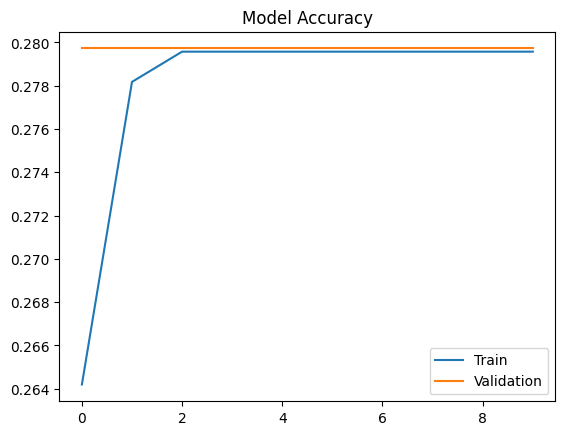

In [15]:
train_acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Model Accuracy Across Both Training Stages')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [13]:
model.save('brain_tumor_model.h5')

## 1) One-Click Colab Export
Run the next cell to create a Colab-ready copy of this notebook as `brain_tumor_colab.ipynb` with outputs cleared and dataset path switched to `/content/dataset`.

In [10]:
import copy
import json
from pathlib import Path

nb_path = Path('brain_tumor.ipynb')
out_path = Path('brain_tumor_colab.ipynb')

nb = json.loads(nb_path.read_text(encoding='utf-8'))
colab_nb = copy.deepcopy(nb)

for cell in colab_nb.get('cells', []):
    if cell.get('cell_type') == 'code':
        cell['execution_count'] = None
        cell['outputs'] = []
        cell['source'] = [
            line.replace("dataset_path = './dataset'", "dataset_path = '/content/dataset'")
            for line in cell.get('source', [])
        ]

colab_nb.setdefault('metadata', {})
colab_nb['metadata']['colab'] = {
    'name': 'brain_tumor_colab.ipynb',
    'provenance': []
}
colab_nb['metadata']['kernelspec'] = {
    'display_name': 'Python 3',
    'language': 'python',
    'name': 'python3'
}
colab_nb['metadata']['accelerator'] = 'GPU'

out_path.write_text(json.dumps(colab_nb, indent=2), encoding='utf-8')
print(f'Created: {out_path.resolve()}')

Created: /Users/anishr/Desktop/BrainTumorProject/brain_tumor_colab.ipynb


## 2) Grad-CAM Inference (MobileNetV2)
Run the next two cells to generate a Grad-CAM heatmap overlay for a sample test image.

In [17]:
import glob
import cv2

def load_and_preprocess_for_gradcam(image_path, img_size=IMG_SIZE):
    img = tf.keras.utils.load_img(image_path, target_size=img_size)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    return arr

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='Conv_1', pred_index=None):
    _ = model(img_array, training=False)
    base = model.layers[0]
    last_conv_layer = base.get_layer(last_conv_layer_name)

    last_conv_model = tf.keras.models.Model(base.input, last_conv_layer.output)

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    for layer in model.layers[1:]:
        x = layer(x)
    classifier_model = tf.keras.models.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_model(img_array)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def overlay_gradcam_on_image(image_path, heatmap, alpha=0.35):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, IMG_SIZE)

    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_uint8 = cv2.resize(heatmap_uint8, IMG_SIZE)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(image, 1 - alpha, heatmap_color, alpha, 0)

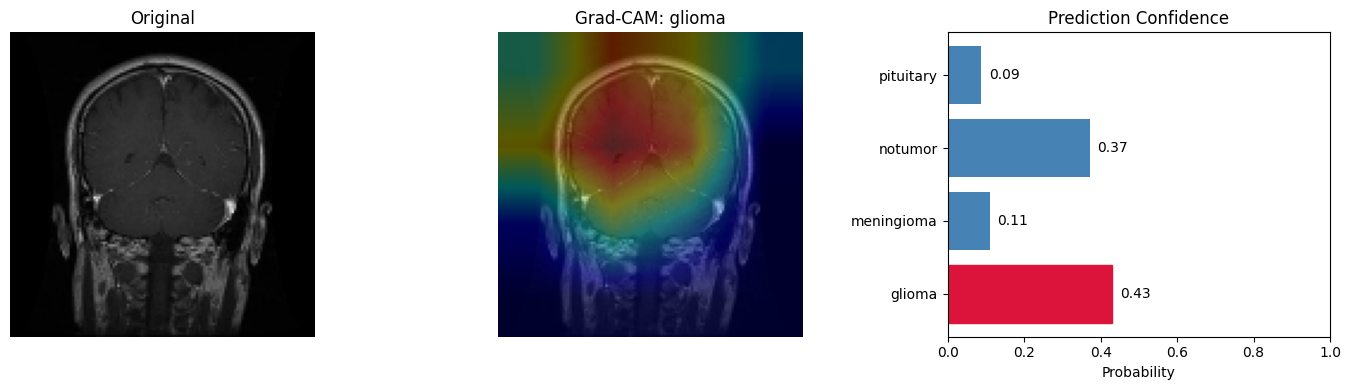

Class legend: {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}


In [19]:
sample_paths = sorted(glob.glob(os.path.join(dataset_path, 'test', '*', '*')))
if not sample_paths:
    raise FileNotFoundError('No test images found in dataset/test/*/*')

sample_image_path = sample_paths[0]
img_array = load_and_preprocess_for_gradcam(sample_image_path)

pred_probs = model.predict(img_array, verbose=0)[0]
pred_class_index = int(np.argmax(pred_probs))

if 'test_data' in globals() and hasattr(test_data, 'class_indices'):
    idx_to_class = {v: k for k, v in test_data.class_indices.items()}
else:
    test_dir = os.path.join(dataset_path, 'test')
    folder_names = sorted([
        d for d in os.listdir(test_dir)
        if os.path.isdir(os.path.join(test_dir, d)) and not d.startswith('.')
    ])
    idx_to_class = {i: name for i, name in enumerate(folder_names)}

class_names = [idx_to_class.get(i, f'class_{i}') for i in range(len(pred_probs))]
pred_class_name = idx_to_class.get(pred_class_index, str(pred_class_index))

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name='Conv_1',
    pred_index=pred_class_index
)
overlay = overlay_gradcam_on_image(sample_image_path, heatmap)

original = tf.keras.utils.load_img(sample_image_path, target_size=IMG_SIZE)

fig = plt.figure(figsize=(14, 4))

ax1 = plt.subplot(1, 3, 1)
ax1.imshow(original)
ax1.set_title('Original')
ax1.axis('off')

ax2 = plt.subplot(1, 3, 2)
ax2.imshow(overlay)
ax2.set_title(f'Grad-CAM: {pred_class_name}')
ax2.axis('off')

ax3 = plt.subplot(1, 3, 3)
bars = ax3.barh(class_names, pred_probs, color='steelblue')
bars[pred_class_index].set_color('crimson')
ax3.set_xlim(0, 1)
ax3.set_xlabel('Probability')
ax3.set_title('Prediction Confidence')

for i, p in enumerate(pred_probs):
    ax3.text(min(p + 0.02, 0.98), i, f'{p:.2f}', va='center')

plt.tight_layout()
plt.show()

print('Class legend:', {i: name for i, name in enumerate(class_names)})

## 6. Saving the Model
Finally, the model is serialized into an H5 file (`brain_tumor_model.h5`). This file is later directly loaded by our `backend_api.py` FastAPI server to orchestrate production-level web inferences without needing to retrain.